# Inspecting the full pipeline for the VAE

In [88]:
from __future__ import annotations
import numpy as np 
import matplotlib.pyplot as plt
import json
import os
import sys 
import tskit 
from pathlib import Path
import torch
import yaml 

In [110]:
# Import the YAML 
with open('/sietch_colab/akapoor/PRS_Portability/config_files/model_hyperparams/vae.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [90]:
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [91]:
processed_data_path = Path('/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0')

In [92]:
# Let's look at the normalized discovery data
norm_discovery_train = np.load(f'{processed_data_path}/discovery_train.npy')
norm_discovery_val = np.load(f'{processed_data_path}/discovery_val.npy')

In [93]:
norm_discovery_train.shape

(4000, 7183)

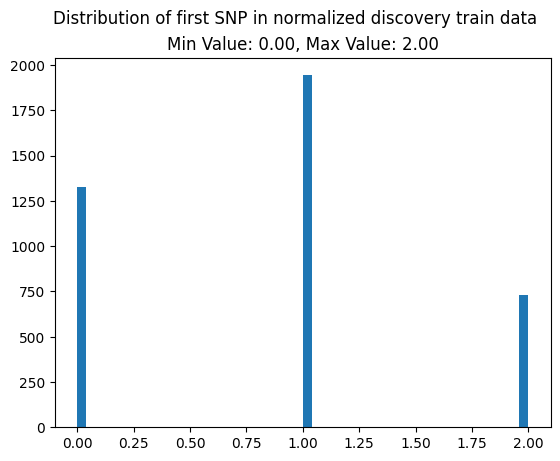

In [94]:
plt.figure()
plt.hist(norm_discovery_train[:,0], bins=50)
plt.suptitle('Distribution of first SNP in normalized discovery train data')
plt.title(f'Min Value: {norm_discovery_train[:,0].min():.2f}, Max Value: {norm_discovery_train[:,0].max():.2f}')
plt.show()

In [95]:
# Print the counts of each unique value across the entire train dataset
unique_all, counts_all = np.unique(norm_discovery_train, return_counts=True)
print(f'TRAINING DATASET')
print(f'Unique values in entire dataset: {unique_all}')
print(f'Counts of unique values in entire dataset: {counts_all}')
print(f'Frequencies of unique values in entire train dataset: {counts_all / norm_discovery_train.size}')
print("=" * 20)
print(f'VALIDATION DATASET')
unique_val, counts_val = np.unique(norm_discovery_val, return_counts=True)
print(f'Unique values in entire dataset: {unique_val}')
print(f'Counts of unique values in entire dataset: {counts_val}')
print(f'Frequencies of unique values in entire validation dataset: {counts_val / norm_discovery_val.size}')

TRAINING DATASET
Unique values in entire dataset: [0. 1. 2.]
Counts of unique values in entire dataset: [17049690  7938403  3743907]
Frequencies of unique values in entire train dataset: [0.59340422 0.27629135 0.13030443]
VALIDATION DATASET
Unique values in entire dataset: [0. 1. 2.]
Counts of unique values in entire dataset: [4262364 1983347  937289]
Frequencies of unique values in entire validation dataset: [0.59339607 0.2761168  0.13048712]


## Visualize the mask 

In [111]:
enabled = config['masking']['enabled']
n_blocks = config['masking']['n_blocks']
block_len = config['masking']['block_len']
mask_frac = config['masking']['mask_frac']
allow_overlap = config['masking']['allow_overlap']
seed = config['seed']
fill = config['masking']['fill']
gaussian_std = config['masking']['gaussian_std']
constant_value = config['masking']['constant_value']
constraint_mode = config['masking']['constraint_mode']


In [112]:
from src.masking import make_mask_and_apply
x = torch.tensor(norm_discovery_train[:64], dtype=torch.float32)   # (B, L)

In [113]:
x_in, mask, used_n_blocks, used_block_len, target_mask_frac, realized_mask_frac = make_mask_and_apply(
    x,
    enabled=enabled,
    constraint_mode=constraint_mode,
    n_blocks=n_blocks,
    block_len=block_len,
    mask_frac=mask_frac,
    allow_overlap=allow_overlap,
    seed=seed,
    fill=fill,
    gaussian_std=gaussian_std,
    constant_value=constant_value,
)


print(f'Input shape: {x.shape}')
print(f'Masked input shape: {x_in.shape}')
print(f'Mask shape: {mask.shape}')
print(f'Used n_blocks: {used_n_blocks}')
print(f'Used block length: {used_block_len}')
print(f'Target mask fraction: {target_mask_frac:.4f}')
print(f'Realized mask fraction: {realized_mask_frac:.4f}')

Input shape: torch.Size([64, 7183])
Masked input shape: torch.Size([64, 7183])
Mask shape: torch.Size([64, 7183])
Used n_blocks: 72
Used block length: 5
Target mask fraction: 0.0500
Realized mask fraction: 0.0501


In [114]:
x

tensor([[1., 0., 0.,  ..., 0., 0., 1.],
        [1., 1., 0.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 0.,  ..., 0., 0., 1.],
        [1., 0., 0.,  ..., 1., 0., 1.],
        [0., 1., 0.,  ..., 2., 0., 0.]])

In [115]:
x_in

tensor([[ 1.,  0.,  0.,  ...,  0.,  0.,  1.],
        [ 1.,  1.,  0.,  ...,  1.,  0.,  1.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        ...,
        [ 0.,  1.,  0.,  ...,  0.,  0.,  1.],
        [ 1.,  0.,  0.,  ..., -1., -1., -1.],
        [ 0.,  1.,  0.,  ...,  2.,  0.,  0.]])

In [116]:
np.unique(x_in.numpy(), return_counts=True)

(array([-1.,  0.,  1.,  2.], dtype=float32),
 array([ 23040, 259074, 121277,  56321]))

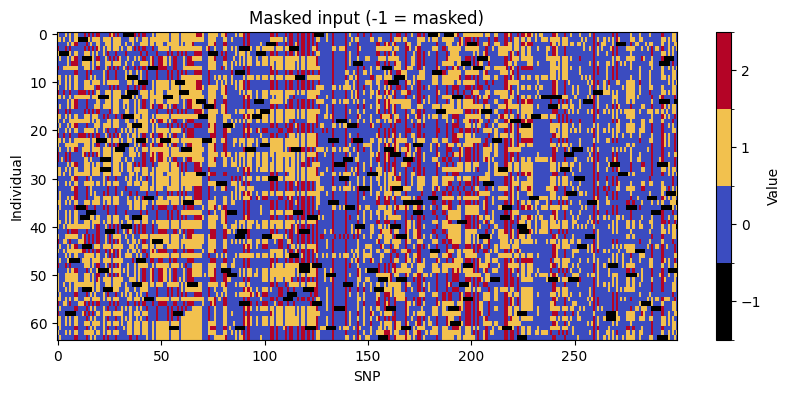

In [117]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# discrete colors for values: -1, 0, 1, 2
colors = [
    "black",     # -1 = masked
    "#3b4cc0",   # 0
    "#f2c14e",   # 1
    "#b40426",   # 2
]
cmap = ListedColormap(colors)
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(10, 4))

subset = x_in[:, :300].cpu().numpy()   # first 300 SNPs

im = plt.imshow(
    subset,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

cbar = plt.colorbar(im, ticks=[-1, 0, 1, 2])
cbar.set_label("Value")

plt.xlabel("SNP")
plt.ylabel("Individual")
plt.title("Masked input (-1 = masked)")
plt.show()

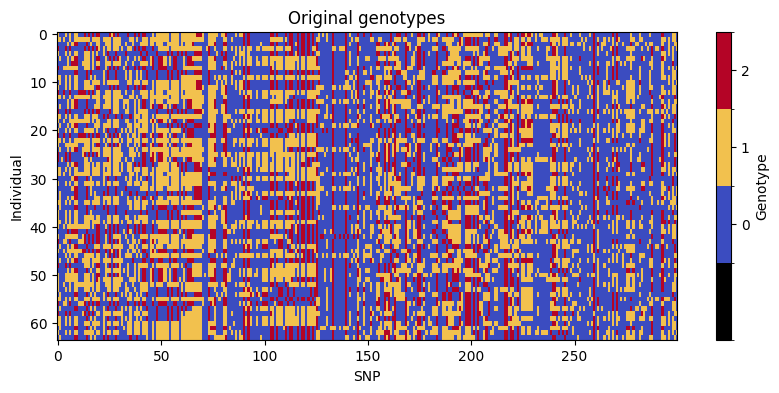

In [118]:
plt.figure(figsize=(10, 4))

subset = x[:, :300].cpu().numpy()

im = plt.imshow(
    subset,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.set_label("Genotype")

plt.xlabel("SNP")
plt.ylabel("Individual")
plt.title("Original genotypes")
plt.show()

In [119]:
## How many values per total SNPs are masked for each individual? 
x_all = torch.tensor(norm_discovery_train, dtype=torch.float32)   # (B, L)
x_in, mask, used_n_blocks, used_block_len, target_mask_frac, realized_mask_frac = make_mask_and_apply(
    x_all,
    enabled=enabled,
    constraint_mode=constraint_mode,
    n_blocks=n_blocks,
    block_len=block_len,
    mask_frac=mask_frac,
    allow_overlap=allow_overlap,
    seed=seed,
    fill=fill,
    gaussian_std=gaussian_std,
    constant_value=constant_value,
)

In [120]:
print("x_all shape:", x_all.shape)
print("masking enabled:", enabled)
print("constraint_mode:", constraint_mode)
print("n_blocks from config:", n_blocks)
print("block_len from config:", block_len)
print("mask_frac from config:", mask_frac)
print("allow_overlap:", allow_overlap)
print("used_n_blocks:", used_n_blocks)
print("used_block_len:", used_block_len)
print("target_mask_frac:", target_mask_frac)
print("realized_mask_frac:", realized_mask_frac)
print("mask sum per sample:", mask.sum(dim=1)[:10])
print("mask frac per sample:", (mask.sum(dim=1).float() / mask.shape[1])[:10])

x_all shape: torch.Size([4000, 7183])
masking enabled: True
constraint_mode: frac_and_len
n_blocks from config: None
block_len from config: 5
mask_frac from config: 0.05
allow_overlap: False
used_n_blocks: 72
used_block_len: 5
target_mask_frac: 0.05
realized_mask_frac: 0.0501183345913887
mask sum per sample: tensor([360, 360, 360, 360, 360, 360, 360, 360, 360, 360])
mask frac per sample: tensor([0.0501, 0.0501, 0.0501, 0.0501, 0.0501, 0.0501, 0.0501, 0.0501, 0.0501,
        0.0501])


In [121]:
print("used_block_len:", used_block_len)
print("mask sum per sample:", mask.sum(dim=1)[:10])
print("mask frac per sample:", (mask.sum(dim=1).float() / mask.shape[1])[:10])

used_block_len: 5
mask sum per sample: tensor([360, 360, 360, 360, 360, 360, 360, 360, 360, 360])
mask frac per sample: tensor([0.0501, 0.0501, 0.0501, 0.0501, 0.0501, 0.0501, 0.0501, 0.0501, 0.0501,
        0.0501])


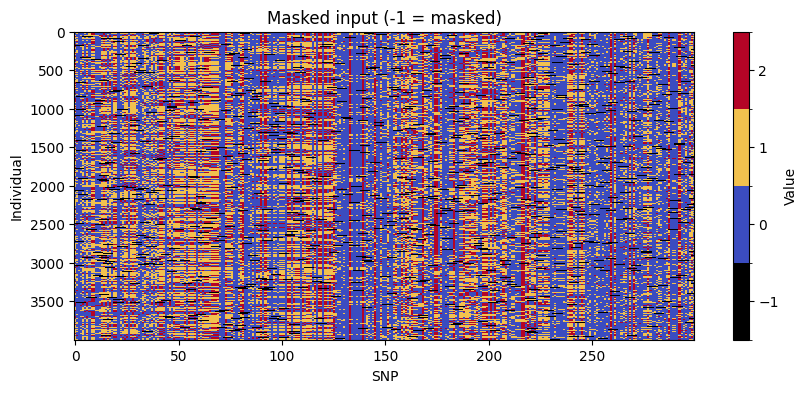

In [122]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# discrete colors for values: -1, 0, 1, 2
colors = [
    "black",     # -1 = masked
    "#3b4cc0",   # 0
    "#f2c14e",   # 1
    "#b40426",   # 2
]
cmap = ListedColormap(colors)
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(10, 4))

subset = x_in[:, :300].cpu().numpy()   # first 300 SNPs

im = plt.imshow(
    subset,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

cbar = plt.colorbar(im, ticks=[-1, 0, 1, 2])
cbar.set_label("Value")

plt.xlabel("SNP")
plt.ylabel("Individual")
plt.title("Masked input (-1 = masked)")
plt.show()

In [123]:
num_masked_per_individual = (x_in == constant_value).sum(dim=1)
total_snps = x_in.shape[1]
masking_fraction_per_individual = num_masked_per_individual / total_snps
print(masking_fraction_per_individual)

tensor([0.0501, 0.0501, 0.0501,  ..., 0.0501, 0.0501, 0.0501])


In [124]:
# What are the counts of 0, 1, 2 in the original input that fall within the mask? 
masked_genotypes = x_all[mask == 1]
unique_masked, counts_masked = torch.unique(masked_genotypes, return_counts=True)
print(f'Unique values in masked positions: {unique_masked}')
print(f'Frequencies of unique values in masked positions: {counts_masked / masked_genotypes.numel()}')

Unique values in masked positions: tensor([0., 1., 2.])
Frequencies of unique values in masked positions: tensor([0.5941, 0.2761, 0.1298])


## Investigating model results

In [125]:
import numpy as np
from pathlib import Path

p = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/recon/train_recon.npz")
d = np.load(p)

x_masked = d["x_masked"]
mask = d["mask"]

print("Unique values at masked positions:", np.unique(x_masked[mask])[:20])
print("Min/max at masked positions:", x_masked[mask].min(), x_masked[mask].max())
print("Unique values overall (small sample):", np.unique(x_masked)[:20])

Unique values at masked positions: [-1.]
Min/max at masked positions: -1.0 -1.0
Unique values overall (small sample): [-1.  0.  1.  2.]


In [136]:
list(d.keys())

['x_true',
 'x_masked',
 'mask',
 'recon',
 'used_n_blocks',
 'used_block_len',
 'target_mask_frac',
 'realized_mask_frac']

In [135]:
d['recon']

array([[[ 0.7138272 ,  0.9839153 ,  2.3616686 , ...,  0.40271485,
          0.8695898 ,  0.5110305 ],
        [ 0.50552356, -0.16817835,  0.3840898 , ..., -0.17265621,
          0.4920575 ,  0.170454  ],
        [-0.09694912, -0.9324353 , -0.8897823 , ..., -0.37567282,
          0.36552027,  0.13932897]],

       [[ 0.5930185 ,  0.21930875,  1.2055094 , ...,  1.2658466 ,
          1.9133189 ,  0.7712016 ],
        [ 0.75217974, -0.06288786,  0.71829534, ...,  0.2422784 ,
          0.48925745,  0.7523577 ],
        [ 0.08546034, -0.8155543 ,  0.40171665, ..., -0.6987921 ,
         -0.42604047,  0.1685065 ]],

       [[ 1.1390984 ,  0.5479068 ,  1.5212529 , ...,  0.91437364,
          1.6921309 ,  0.90648454],
        [ 0.33413935, -0.60671616, -0.53705037, ...,  0.07223457,
          0.30049622,  0.53820395],
        [ 0.16268417, -0.1923022 , -0.5644038 , ..., -0.22968471,
         -0.36940056,  0.02096043]],

       ...,

       [[ 0.6108777 , -0.00883709,  1.4278091 , ...,  0.621992 

Confidence Calibration Plot: how confidently did my probabilities assign

In [130]:
def plot_confidence_reliability(npz_path, where="masked_only", n_bins=10):
    data = np.load(npz_path)
    print(data.files)

    x_true = data["x_true"].astype(int)
    mask = data["mask"].astype(bool)
    probs = np.stack([data["prob_0"], data["prob_1"], data["prob_2"]], axis=1)  # (N,3,L)
    probs = probs.transpose(0, 2, 1)  # (N,L,3)

    pred = probs.argmax(axis=-1)
    conf = probs.max(axis=-1)

    if where == "masked_only":
        sel = mask
    elif where == "unmasked_only":
        sel = ~mask
    elif where == "all":
        sel = np.ones_like(mask, dtype=bool)
    else:
        raise ValueError

    y_true = x_true[sel]
    y_pred = pred[sel]
    conf = conf[sel]

    correct = (y_true == y_pred).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(conf, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    bin_acc = []
    bin_conf = []
    bin_count = []

    for b in range(n_bins):
        idx = bin_ids == b
        if idx.sum() == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_count.append(0)
        else:
            bin_acc.append(correct[idx].mean())
            bin_conf.append(conf[idx].mean())
            bin_count.append(idx.sum())

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect calibration")
    plt.plot(bin_conf, bin_acc, marker="o", label="model")
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Empirical accuracy")
    plt.title(f"Reliability plot: {Path(npz_path).name} [{where}]")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    print("Bin counts:", bin_count)

In [131]:
plot_confidence_reliability(p, where="masked_only", n_bins=10)

['x_true', 'x_masked', 'mask', 'recon', 'used_n_blocks', 'used_block_len', 'target_mask_frac', 'realized_mask_frac']


KeyError: 'prob_0 is not a file in the archive'

In [ ]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

base = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae")

rows = []

for blocklen_dir in sorted(base.glob("vae__nblocks*")):
    blocklen_str = blocklen_dir.name.replace("vae__nblocks", "")
    blocklen = int(blocklen_str)

    summary = blocklen_dir / "0/rep0/diagnostics/balanced_accuracy_summary.txt"
    if not summary.exists():
        continue

    with open(summary) as f:
        for line in f:
            if line.startswith("val:"):
                m = re.search(r"bal_acc_all=([0-9.]+)", line)
                if m:
                    rows.append({
                        "nblocks": blocklen,
                        "val_balanced_accuracy": float(m.group(1))
                    })

df = pd.DataFrame(rows).sort_values("nblocks")
display(df)

plt.figure(figsize=(6,4))
plt.plot(df["nblocks"], df["val_balanced_accuracy"], marker="o")
plt.xscale("log")
plt.xlabel("nblocks")
plt.ylabel("validation balanced accuracy")
plt.title("Validation balanced accuracy vs nblocks")
plt.grid(True)
plt.show()